<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de Lenguaje Natural
# Sentence Transformers y FAISS

# **Sentence Transformer**

Importamos lo necesario

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

Escribimos oraciones de distintos tópicos

In [ ]:
chunks = [
    # Geografía
    "La capital de Francia es París.",
    "Madrid es la capital de España.",

    # Biología
    "La fotosíntesis convierte la energía solar en energía química.",
    "Las plantas necesitan luz solar para crecer.",

    # Programación
    "Python es un lenguaje de programación muy usado en IA.",
    "JavaScript se utiliza principalmente en desarrollo web.",
]

Obtenemos los embeddings de las oraciones

In [ ]:
embedder = SentenceTransformer("BAAI/bge-small-en")

embeddings = embedder.encode(
    chunks,
    convert_to_numpy=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
print("Shape embeddings:", embeddings.shape)

Shape embeddings: (6, 384)


SOLO PARA PROBAR QUE SON EMBEDDINGS UTILES


Reducimos las dimensiones a 2D para visualizar

In [ ]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

Visualizamos

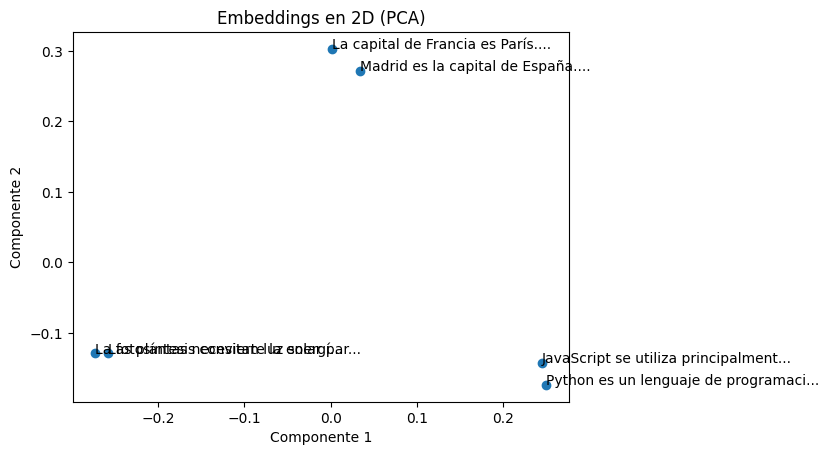

In [ ]:
plt.figure()
plt.scatter(reduced[:, 0], reduced[:, 1])

# Etiquetas
for i, txt in enumerate(chunks):
    plt.annotate(txt[:35] + "...", (reduced[i, 0], reduced[i, 1]))

plt.title("Embeddings en 2D (PCA)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

# FAISS

In [ ]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 43.5 MB/s eta 0:00:00


Importamos lo necesario

In [ ]:
import faiss
import numpy as np

Creamos vectores manuales

In [ ]:
vectors = np.array([
    [1.0, 2.0],  # punto 0
    [2.0, 3.0],  # punto 1
    [10.0, 10.0] # punto 2 (lejos)
]).astype('float32')

Creamos el indice.

Para usar similitud coseno:

`faiss.normalize_L2(vectors)`

`index = faiss.IndexFlatIP(dimension)`

In [ ]:
dimension = 2
index = faiss.IndexFlatL2(dimension)

Añadimos los vectores

In [ ]:
index.add(vectors)

Realizamos un query (nuevo punto)

In [ ]:
query = np.array([[1.5, 2.5]]).astype('float32')

Buscamos los mas cercanos

In [ ]:
D, I = index.search(query, k=2)

print("Índices más cercanos:", I)
print("Distancias:", D)

Índices más cercanos: [[0 1]]
Distancias: [[0.5 0.5]]


Visualizamos

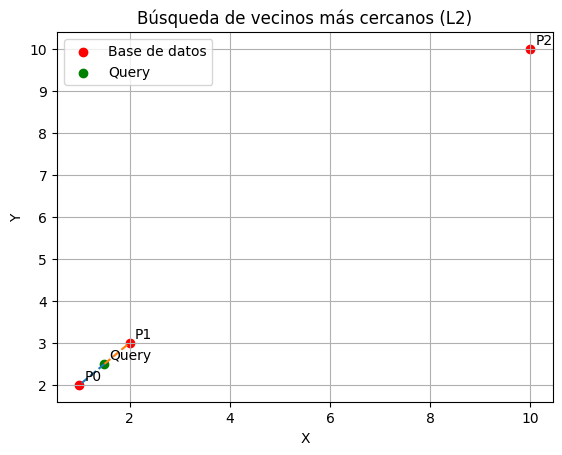

In [ ]:
plt.figure()

plt.scatter(vectors[:, 0], vectors[:, 1], color="red", label="Base de datos")
plt.scatter(query[:, 0], query[:, 1], color="green", label="Query")

for i, v in enumerate(vectors):
    plt.text(v[0] + 0.1, v[1] + 0.1, f"P{i}")

plt.text(query[0][0] + 0.1, query[0][1] + 0.1, "Query")

# Líneas opcionales hacia vecinos más cercanos
for idx in I[0]:  # usa los resultados de FAISS
    neighbor = vectors[idx]
    plt.plot(
        [query[0][0], neighbor[0]],
        [query[0][1], neighbor[1]],
        linestyle="--"
    )

plt.title("Búsqueda de vecinos más cercanos (L2)")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid()

plt.show()